In [1]:
# Customer Segmentation with RFM & K-Means (Colab-ready, CSV or Excel)
import io
import numpy as np
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -------------------------
# 1) Upload file
# -------------------------
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded:", filename)



Saving OnlineRetail.csv to OnlineRetail.csv
Uploaded: OnlineRetail.csv


In [2]:
# -------------------------
# 2) Load file (CSV or XLSX)
# -------------------------
if filename.lower().endswith('.csv'):
    df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='latin1')
elif filename.lower().endswith(('.xls', '.xlsx')):
    df = pd.read_excel(io.BytesIO(uploaded[filename]))
else:
    raise ValueError("Only CSV or Excel files are supported.")


In [3]:
# -------------------------
# 3) Quick checks / clean column names
# -------------------------
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
print(df.columns)
print(df.head())


Shape: (541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [4]:
# -------------------------
# 4) Data cleaning
# -------------------------
# Convert InvoiceDate to datetime (coerce bad values to NaT)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Drop rows without CustomerID or InvoiceDate (cannot use them for RFM)
df = df.dropna(subset=['CustomerID', 'InvoiceDate'])

# Ensure InvoiceNo is string and drop cancellations (starting with 'C' or 'c')
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df = df[~df['InvoiceNo'].str.startswith('C', na=False)]

# Convert Quantity and UnitPrice to numeric (coerce bad values)
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')

# Keep only positive quantity and positive unit price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Calculate TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Convert CustomerID to int if possible (after dropna)
# if CustomerID contains decimals because of csv parse, cast safely:
df['CustomerID'] = df['CustomerID'].astype(int)

print("After cleaning shape:", df.shape)

After cleaning shape: (397884, 9)


In [5]:
# -------------------------
# 5) RFM calculation
# -------------------------
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date for Recency:", reference_date.date())

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency (days)
    'InvoiceNo': 'nunique',                                    # Frequency = unique invoices
    'TotalPrice': 'sum'                                        # Monetary = total spend
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Remove customers with zero or negative monetary (if any)
rfm = rfm[rfm['Monetary'] > 0].copy()

print("RFM sample:")
print(rfm.head())

Reference date for Recency: 2011-12-10
RFM sample:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40


In [6]:
# -------------------------
# 6) Prepare for clustering
# - apply log1p to reduce skew on Frequency & Monetary (optional but recommended)
# -------------------------
rfm_for_scaling = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_for_scaling['Frequency'] = np.log1p(rfm_for_scaling['Frequency'])
rfm_for_scaling['Monetary'] = np.log1p(rfm_for_scaling['Monetary'])
# (we keep Recency as-is; you can log1p it too if you want)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_for_scaling)


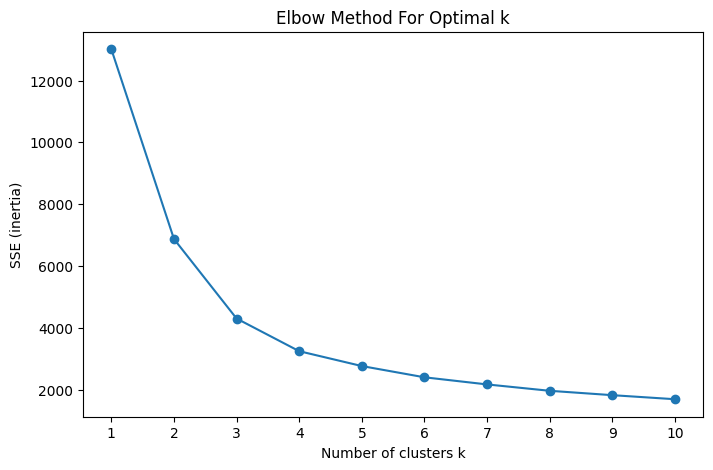

In [7]:
# -------------------------
# 7) Elbow method to pick k
# -------------------------
sse = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, sse, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (inertia)')
plt.title('Elbow Method For Optimal k')
plt.xticks(K)
plt.show()

In [8]:
# -------------------------
# 8) Fit final KMeans (choose k from elbow, e.g., k=4)
# -------------------------
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels = kmeans.fit_predict(rfm_scaled)
rfm['Cluster'] = labels

In [9]:
# -------------------------
# 9) Interpret cluster centers in original scale
# -------------------------
centers_scaled = kmeans.cluster_centers_                          # in scaled (z) space
centers_unscaled = scaler.inverse_transform(centers_scaled)       # back to log-space for F & M
# convert Frequency and Monetary back from log1p
centers_original = centers_unscaled.copy()
centers_original[:, 1] = np.expm1(centers_unscaled[:, 1])  # Frequency
centers_original[:, 2] = np.expm1(centers_unscaled[:, 2])  # Monetary

centers_df = pd.DataFrame(centers_original, columns=['Recency','Frequency','Monetary'])
centers_df['Cluster'] = range(k_final)
print("\nCluster centers (approx in original RFM units):")
print(centers_df.round(2))


Cluster centers (approx in original RFM units):
   Recency  Frequency  Monetary  Cluster
0    45.40       4.02   1381.86        0
1    58.14       1.44    318.38        1
2   259.18       1.29    279.41        2
3    19.48      13.17   5549.88        3


In [10]:
# -------------------------
# 10) Cluster summary (counts + means)
# -------------------------
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID':'CustomerCount'}).reset_index()

print("\nCluster summary (means):")
print(cluster_summary)



Cluster summary (means):
   Cluster     Recency  Frequency      Monetary  CustomerCount
0        0   45.418798   4.268141   1667.669657           1447
1        1   58.139368   1.519397    392.888779           1392
2        2  259.183847   1.375133    390.202827            941
3        3   19.498208  16.034050  10007.540986            558


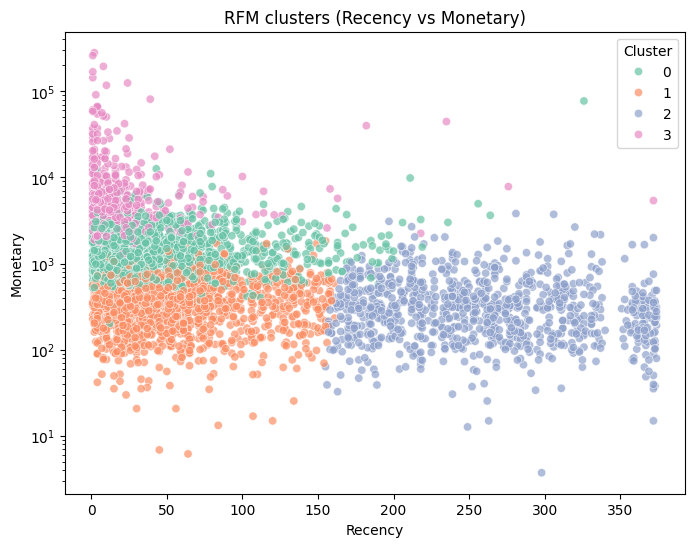

In [11]:
# -------------------------
# 11) Visualization
# -------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2', alpha=0.7)
plt.title('RFM clusters (Recency vs Monetary)')
plt.yscale('log')  # optional: monetary often skewed -> log scale helps visualization
plt.show()

In [12]:
# -------------------------
# 12) Save results (optional)
# -------------------------
rfm.to_csv('rfm_with_clusters.csv', index=False)
print("Saved rfm_with_clusters.csv")

print("\n📌 Cluster Summary:")
print(cluster_summary)

Saved rfm_with_clusters.csv

📌 Cluster Summary:
   Cluster     Recency  Frequency      Monetary  CustomerCount
0        0   45.418798   4.268141   1667.669657           1447
1        1   58.139368   1.519397    392.888779           1392
2        2  259.183847   1.375133    390.202827            941
3        3   19.498208  16.034050  10007.540986            558


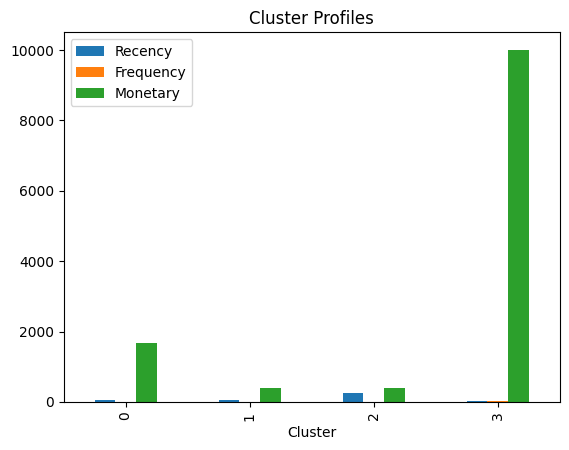

In [13]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().plot(kind='bar')
plt.title("Cluster Profiles")
plt.show()

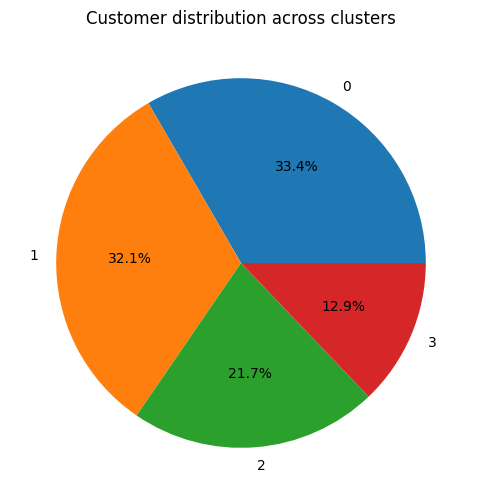

In [14]:
rfm['Cluster'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Customer distribution across clusters")
plt.ylabel("")
plt.show()

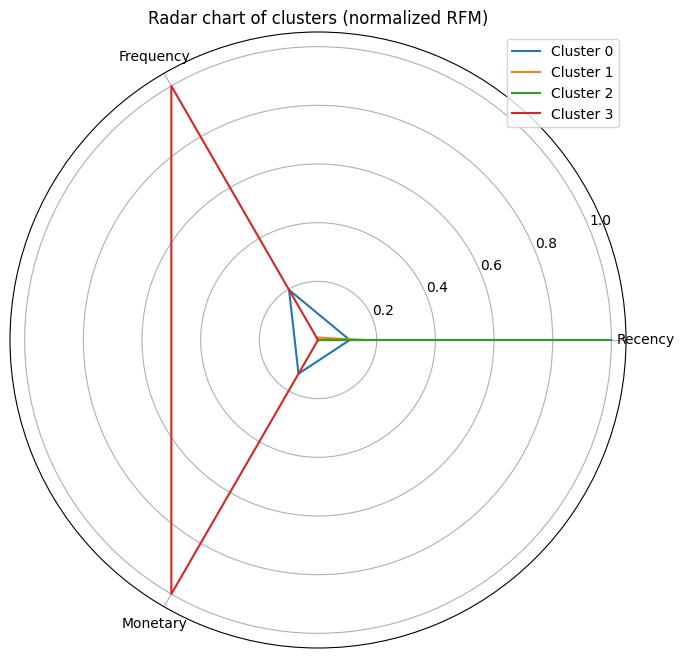

In [15]:
from math import pi

cluster_means = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
categories = list(cluster_means.columns)

# Normalize for fair comparison
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

plt.figure(figsize=(8,8))
for i, row in cluster_means_norm.iterrows():
    values = row.values.flatten().tolist()
    values += values[:1]  # close the circle
    angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]
    plt.polar(angles, values, label=f"Cluster {i}")
plt.xticks([n / float(len(categories)) * 2 * pi for n in range(len(categories))], categories)
plt.title("Radar chart of clusters (normalized RFM)")
plt.legend()
plt.show()

In [17]:
# -------------------------
# Cluster Labeling
# -------------------------

# Step 1: Calculate cluster means (RFM + number of customers)
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID':'CustomerCount'}).reset_index()

print("\nCluster summary (means):")
print(cluster_summary)

# Step 2: Define labeling logic based on RFM values
def label_cluster(row):
    if row['Recency'] < cluster_summary['Recency'].mean() and \
       row['Frequency'] > cluster_summary['Frequency'].mean() and \
       row['Monetary'] > cluster_summary['Monetary'].mean():
        return "💎 Champions"
    elif row['Recency'] < cluster_summary['Recency'].mean() and \
         row['Frequency'] > cluster_summary['Frequency'].mean():
        return "🔥 Loyal Customers"
    elif row['Recency'] > cluster_summary['Recency'].mean() and \
         row['Monetary'] > cluster_summary['Monetary'].mean():
        return "⚠️ At Risk"
    elif row['Recency'] > cluster_summary['Recency'].mean() and \
         row['Frequency'] < cluster_summary['Frequency'].mean():
        return "💤 Lost Customers"
    else:
        return "🌱 New / Low Value"

# Step 3: Apply labeling to cluster summary
cluster_summary['Label'] = cluster_summary.apply(label_cluster, axis=1)

print("\nCluster Summary with Labels:")
print(cluster_summary)

# Step 4: Map labels back to the RFM dataset
label_map = cluster_summary.set_index('Cluster')['Label'].to_dict()
rfm['ClusterLabel'] = rfm['Cluster'].map(label_map)

# Step 5: Save final results (optional)
rfm.to_csv("rfm_with_cluster_labels.csv", index=False)



Cluster summary (means):
   Cluster     Recency  Frequency      Monetary  CustomerCount
0        0   45.418798   4.268141   1667.669657           1447
1        1   58.139368   1.519397    392.888779           1392
2        2  259.183847   1.375133    390.202827            941
3        3   19.498208  16.034050  10007.540986            558

Cluster Summary with Labels:
   Cluster     Recency  Frequency      Monetary  CustomerCount  \
0        0   45.418798   4.268141   1667.669657           1447   
1        1   58.139368   1.519397    392.888779           1392   
2        2  259.183847   1.375133    390.202827            941   
3        3   19.498208  16.034050  10007.540986            558   

               Label  
0  🌱 New / Low Value  
1  🌱 New / Low Value  
2   💤 Lost Customers  
3        💎 Champions  


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128164 (\N{SLEEPING SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128164 (\N{SLEEPING SYMBOL}) missing from font(s) Deja

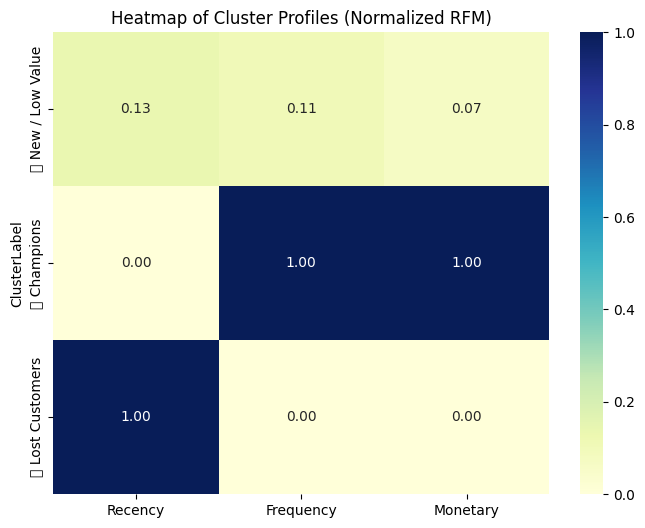

In [18]:
# -------------------------
# Heatmap of Cluster Means (normalized)
# -------------------------
plt.figure(figsize=(8,6))
cluster_means = rfm.groupby('ClusterLabel')[['Recency','Frequency','Monetary']].mean()

# Normalize for fair comparison
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

sns.heatmap(cluster_means_norm, annot=True, cmap="YlGnBu", cbar=True, fmt=".2f")
plt.title("Heatmap of Cluster Profiles (Normalized RFM)")
plt.show()

📌 Insights Summary
1. Cluster 3 - 💎 Champions

Customers with the highest frequency and monetary values.

They purchase often and spend significantly.

Small group (12.9%) but extremely valuable for revenue.

Strategy: Focus on retention, loyalty programs, and VIP offers.

2. Cluster 0 - 🌱 New / Low Value

Largest group (33.4% of customers).

Low purchase frequency and relatively low spend.

Strategy: Run promotions, discounts, and onboarding campaigns to convert them into active buyers.

3. Cluster 1 - 🌱 New / Low Value

Similar to Cluster 0 but with slightly different behavior.

Medium size (32.1%).

Strategy: Nurture with targeted marketing to increase purchase frequency.

4. Cluster 2 - 💤 Lost Customers

Customers with very high recency (last purchase was a long time ago).

Low frequency and monetary value.

Represent 21.7% of customers.

Strategy: Reactivation campaigns, win-back emails, or reminders.

🔑 Key Takeaway

About 1/3 of customers are high potential (Champions + New/Low Value).

Champions drive revenue, but the majority are low-value or lost customers.

Retention and reactivation should be the top priority, while also nurturing new buyers.